# 05 - Visualizacao da Segmentacao Bruta

Le as tabelas analiticas persistidas pelo notebook 04, reconstrói a base linha a linha em memoria e exporta graficos e tabelas em PNG+CSV para consumo posterior por IA.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams['figure.max_open_warning'] = 0
import pandas as pd
from IPython.display import display

root_dir = Path.cwd()
if not (root_dir / 'src').exists() and (root_dir.parent / 'src').exists():
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.analysis import MetricsCollector
from src.io.path_resolver import PathResolver
from src.repositories import (
    AnaliseSegmentacaoBrutaEstabilidadeRepository,
    AnaliseSegmentacaoBrutaInteracaoTagModeloRepository,
    AnaliseSegmentacaoBrutaIntervaloConfiancaRepository,
    AnaliseSegmentacaoBrutaResumoModeloRepository,
)
from src.visualization import (
    build_artifact_output_dir,
    build_artifact_stem,
    export_figure_with_csv,
    export_table_csv,
    plot_metric_bars_with_ci_by_model,
    plot_metric_correlation_heatmap,
    plot_metric_distribution_by_model,
    plot_metric_scatter,
    plot_model_tag_interaction_heatmap,
    plot_simple_regression,
    plot_stability_bars,
)


/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento das tabelas analiticas e da base linha a linha

A visualizacao agora usa apenas o que e mais util para leitura do projeto: resumos por modelo, intervalos de confianca, estabilidade entre execucoes, interacoes com dificuldade e a base linha a linha para correlacao e regressao.


In [2]:
def _registros_para_dataframe(registros, columns):
    return pd.DataFrame([{column: getattr(registro, column) for column in columns} for registro in registros], columns=columns)

metric_names = ['auprc', 'soft_dice', 'brier_score']
metric_pairs = [('auprc', 'soft_dice'), ('auprc', 'brier_score'), ('soft_dice', 'brier_score')]
regression_metrics = ['soft_dice', 'brier_score']
interaction_metrics = ['auprc', 'soft_dice', 'brier_score']
path_resolver = PathResolver.from_config()
artifact_output_dir = build_artifact_output_dir(
    path_resolver.generated_dir,
    'notebook_05_segmentacao_bruta',
)

collector = MetricsCollector(force_recalculate=False)
df_base = collector.collect_all_metrics()

resumo_modelo_repository = AnaliseSegmentacaoBrutaResumoModeloRepository()
intervalo_confianca_repository = AnaliseSegmentacaoBrutaIntervaloConfiancaRepository()
estabilidade_repository = AnaliseSegmentacaoBrutaEstabilidadeRepository()
interacao_tag_modelo_repository = AnaliseSegmentacaoBrutaInteracaoTagModeloRepository()

df_resumo_modelo = _registros_para_dataframe(
    resumo_modelo_repository.list(),
    ['nome_modelo', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_intervalo_confianca = _registros_para_dataframe(
    intervalo_confianca_repository.list(),
    ['nome_modelo', 'metric_name', 'statistic_name', 'count', 'estimate', 'ci_low', 'ci_high', 'confidence_level', 'n_resamples', 'higher_is_better'],
)
df_estabilidade = _registros_para_dataframe(
    estabilidade_repository.list(),
    ['nome_modelo', 'metric_name', 'count_execucoes', 'mean_execucoes', 'std_execucoes', 'cv_execucoes', 'amplitude_execucoes', 'melhor_execucao', 'pior_execucao', 'higher_is_better'],
)
df_interacoes_tag_modelo = _registros_para_dataframe(
    interacao_tag_modelo_repository.list(),
    ['nome_modelo', 'tag_name', 'metric_name', 'count_com_tag', 'count_sem_tag', 'mean_com_tag', 'mean_sem_tag', 'median_com_tag', 'median_sem_tag', 'delta_mean', 'delta_median', 'relative_delta_mean', 'adjusted_delta_mean', 'adjusted_delta_median', 'impact_direction', 'higher_is_better'],
)

print(f'Registros da base linha a linha: {len(df_base)}')
print(f'Resumo por modelo: {len(df_resumo_modelo)}')
print(f'Intervalos de confianca: {len(df_intervalo_confianca)}')
print(f'Estabilidade entre execucoes: {len(df_estabilidade)}')
print(f'Interacoes modelo x tag: {len(df_interacoes_tag_modelo)}')
print(f'Diretorio de artefatos: {artifact_output_dir}')


✓ Métricas carregadas do SQLite
Registros da base linha a linha: 16254
Resumo por modelo: 42
Intervalos de confianca: 84
Estabilidade entre execucoes: 42
Interacoes modelo x tag: 252
Diretorio de artefatos: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_05_segmentacao_bruta


## Estatistica descritiva univariada

Este bloco resume cada metrica por modelo usando estimativa central e intervalo de confianca, o que torna a comparacao mais informativa do que olhar apenas medias isoladas.


metric_name,nome_modelo,auprc,brier_score,soft_dice
0,birefnet-cod,0.985748,0.008668,0.977765
1,birefnet-dis,0.954597,0.013671,0.951632
2,birefnet-general,0.989522,0.006003,0.983332
3,birefnet-general-lite,0.986632,0.007568,0.981080
4,birefnet-hrsod,0.994105,0.006055,0.979967
5,birefnet-massive,0.986185,0.008849,0.975362
6,birefnet-portrait,0.987144,0.008421,0.977672
7,isnet-anime,0.813369,0.084392,0.574988
8,isnet-general-use,0.991877,0.009025,0.966871
9,sam,0.799289,0.078031,0.773514


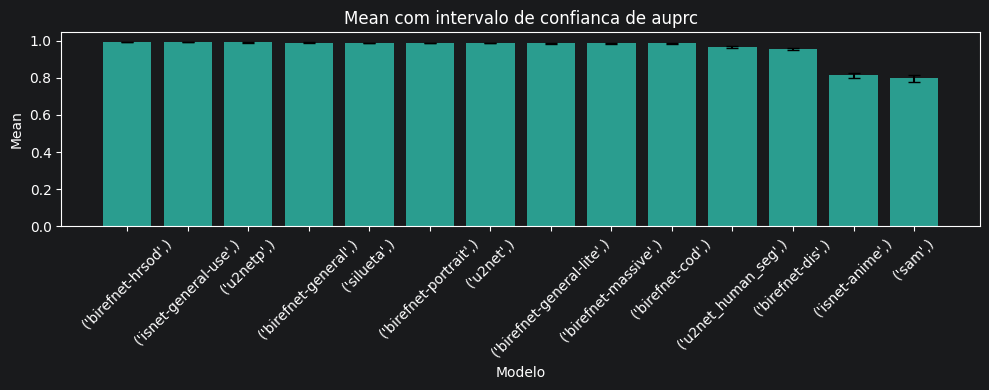

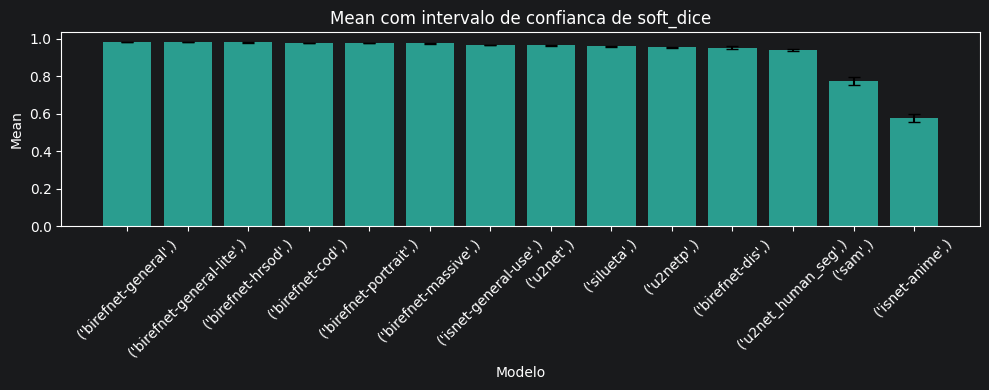

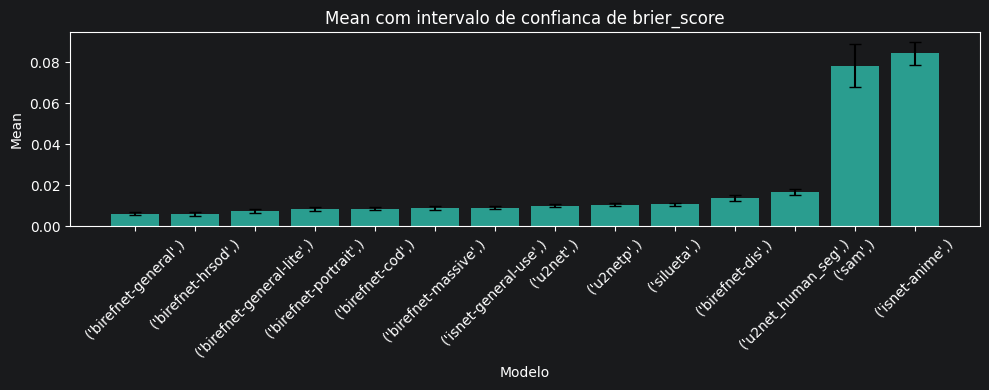

In [3]:
texto_univariada = 'Este bloco resume cada metrica por modelo usando estimativa central e intervalo de confianca, o que torna a comparacao mais informativa do que olhar apenas medias isoladas.'
df_tabela_univariada = df_resumo_modelo.pivot(index='nome_modelo', columns='metric_name', values='mean').sort_index().reset_index()
display(df_tabela_univariada)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_05_segmentacao_bruta', 'tabela', 'resumo_modelo_media'),
    df_tabela_univariada,
)

for metric_name in metric_names:
    df_plot = df_intervalo_confianca.loc[
        (df_intervalo_confianca['metric_name'] == metric_name)
        & (df_intervalo_confianca['statistic_name'] == 'mean')
    ].copy()
    fig, _ = plot_metric_bars_with_ci_by_model(df_resumo_modelo, df_intervalo_confianca, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'univariada', 'mean_ic', metric_name, 'por_modelo'),
        fig,
        df_plot[['nome_modelo', 'metric_name', 'statistic_name', 'count', 'estimate', 'ci_low', 'ci_high', 'confidence_level', 'n_resamples', 'higher_is_better']],
    )
    plt.show()
    plt.close(fig)


## Distribuicoes por modelo

Os boxplots mostram densidade, centralidade e dispersao diretamente na base linha a linha, complementando os intervalos de confianca com a forma da distribuicao.


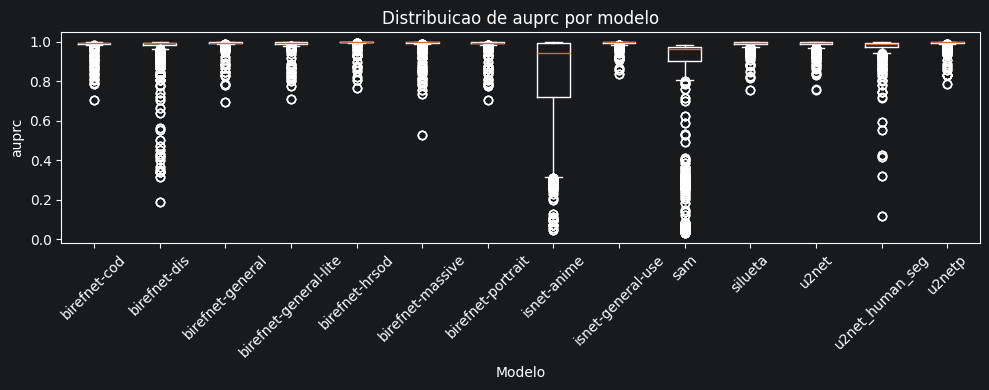

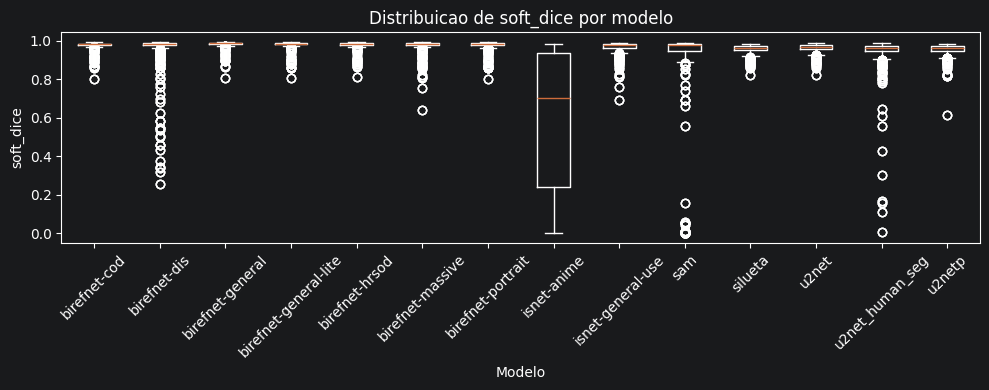

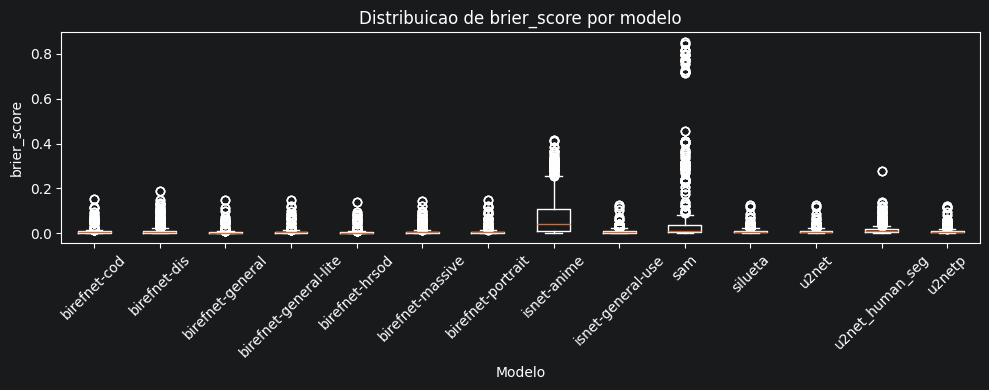

In [4]:
texto_distribuicao = 'Os boxplots mostram densidade, centralidade e dispersao diretamente na base linha a linha, complementando os intervalos de confianca com a forma da distribuicao.'

for metric_name in metric_names:
    df_plot = df_base[['modelo', metric_name, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_metric_distribution_by_model(df_base, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'distribuicao', metric_name, 'por_modelo'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Estabilidade entre execucoes

Este bloco resume a consistencia entre execucoes por modelo. As barras mostram `cv_execucoes` em ordem crescente: quanto menor o coeficiente de variacao, mais estavel e repetivel foi o comportamento do modelo.


,nome_modelo,metric_name,count_execucoes,mean_execucoes,std_execucoes,cv_execucoes,amplitude_execucoes,melhor_execucao,pior_execucao,higher_is_better
0,birefnet-cod,auprc,3,0.985748,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
3,birefnet-dis,auprc,3,0.954597,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
9,birefnet-general-lite,auprc,3,0.986632,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
12,birefnet-hrsod,auprc,3,0.994105,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
15,birefnet-massive,auprc,3,0.986185,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
18,birefnet-portrait,auprc,3,0.987144,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
27,sam,auprc,3,0.799289,0.000000e+00,0.000000e+00,0.000000e+00,1,3,True
6,birefnet-general,auprc,3,0.989522,1.359740e-16,1.374138e-16,0.000000e+00,1,3,True
39,u2netp,auprc,3,0.991592,2.487839e-08,2.508934e-08,4.309063e-08,1,2,True
24,isnet-general-use,auprc,3,0.991877,8.305121e-08,8.373140e-08,1.438489e-07,2,3,True


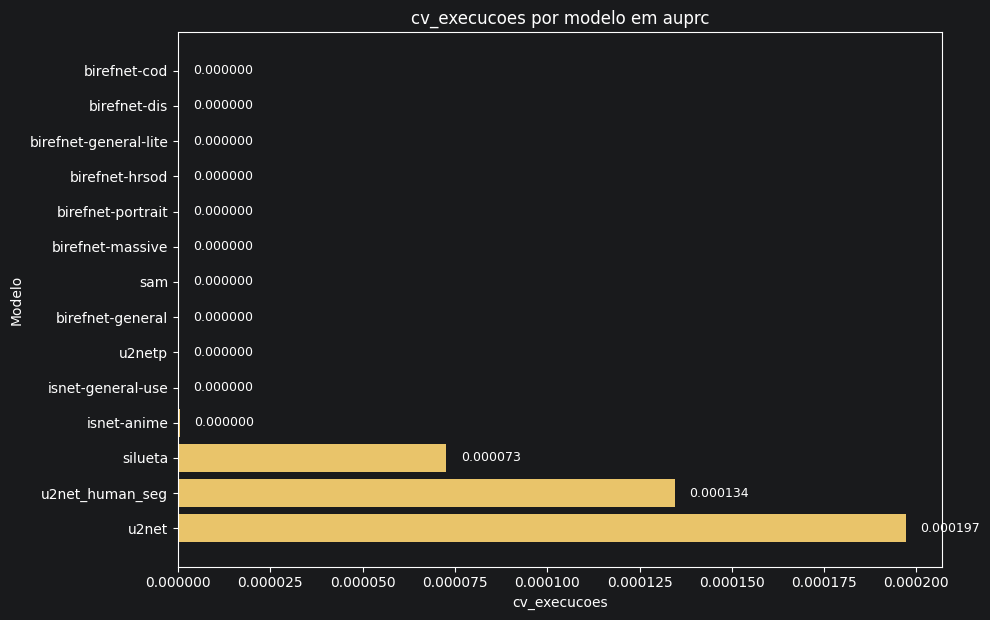

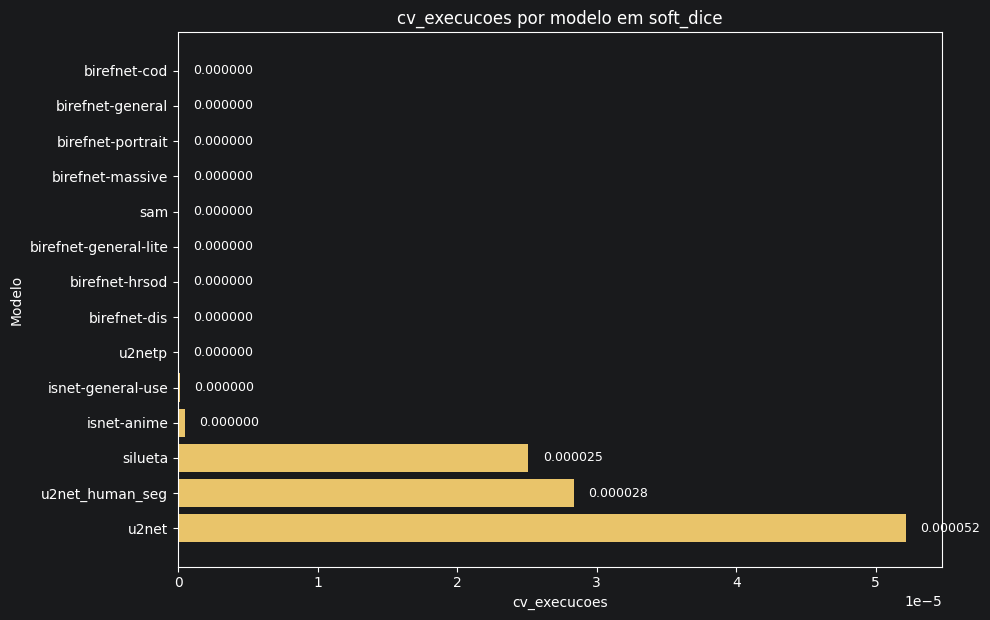

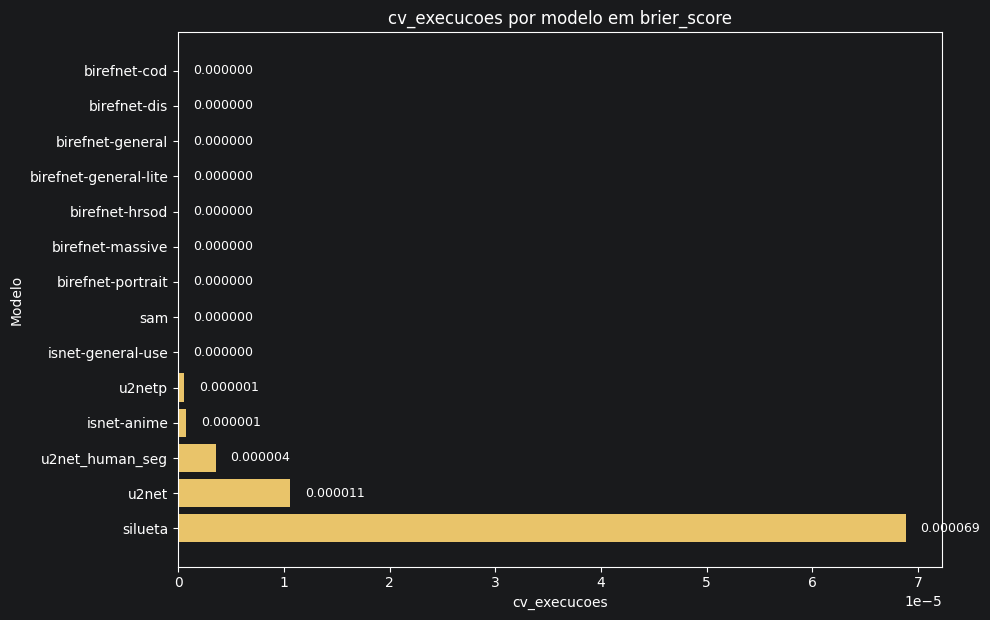

In [5]:
texto_estabilidade = 'Este bloco resume a consistencia entre execucoes por modelo. As barras mostram cv_execucoes em ordem crescente: quanto menor o coeficiente de variacao, mais estavel e repetivel foi o comportamento do modelo.'
df_tabela_estabilidade = df_estabilidade.sort_values(['metric_name', 'cv_execucoes', 'nome_modelo']).copy()
display(df_tabela_estabilidade)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_05_segmentacao_bruta', 'tabela', 'estabilidade'),
    df_tabela_estabilidade,
)

for metric_name in metric_names:
    df_plot = df_estabilidade.loc[df_estabilidade['metric_name'] == metric_name, ['nome_modelo', 'metric_name', 'cv_execucoes', 'count_execucoes', 'mean_execucoes', 'std_execucoes', 'amplitude_execucoes', 'melhor_execucao', 'pior_execucao', 'higher_is_better']].copy()
    fig, _ = plot_stability_bars(df_estabilidade, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'estabilidade', 'cv_execucoes', metric_name, 'por_modelo'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Analise bivariada e correlacao

Aqui avaliamos se as metricas contam historias complementares ou redundantes, usando graficos bivariados e matrizes de correlacao de Pearson e Spearman.


,metric_name,auprc,soft_dice,brier_score
0,auprc,1.000000,0.906853,-0.693278
1,soft_dice,0.906853,1.000000,-0.744267
2,brier_score,-0.693278,-0.744267,1.000000


,metric_name,auprc,soft_dice,brier_score
0,auprc,1.000000,0.563515,-0.594622
1,soft_dice,0.563515,1.000000,-0.654073
2,brier_score,-0.594622,-0.654073,1.000000


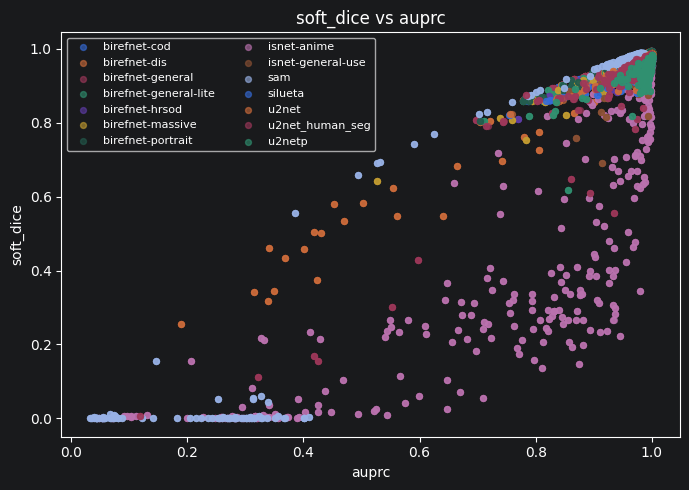

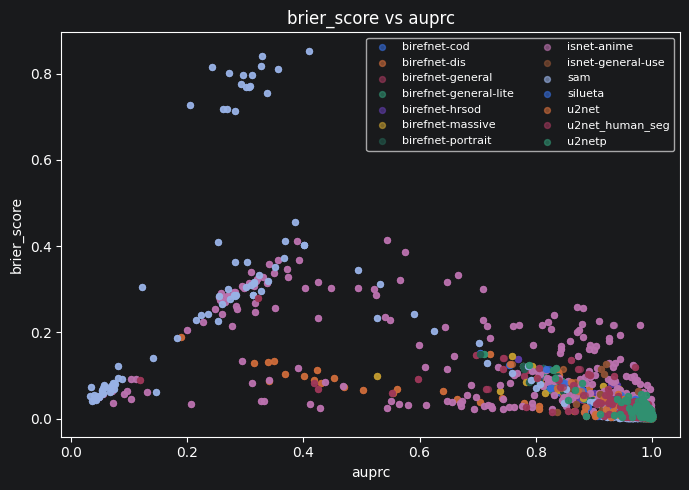

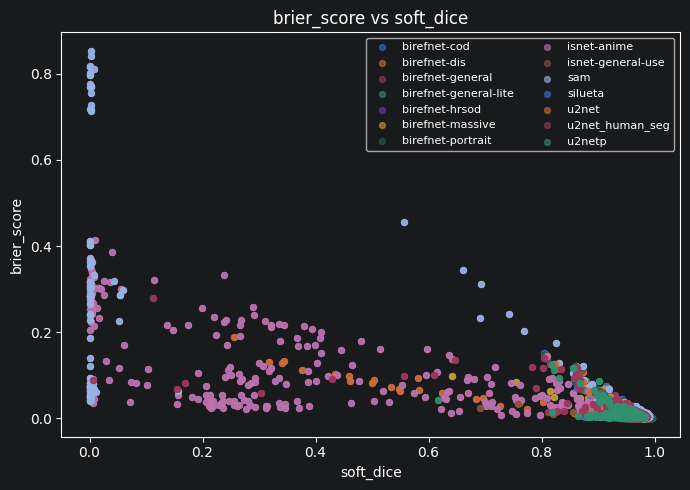

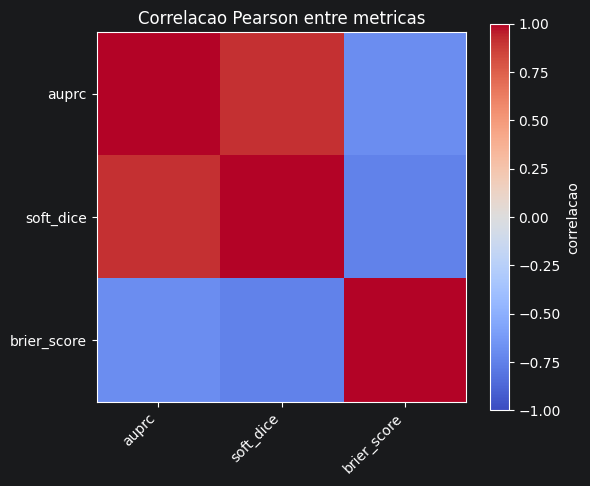

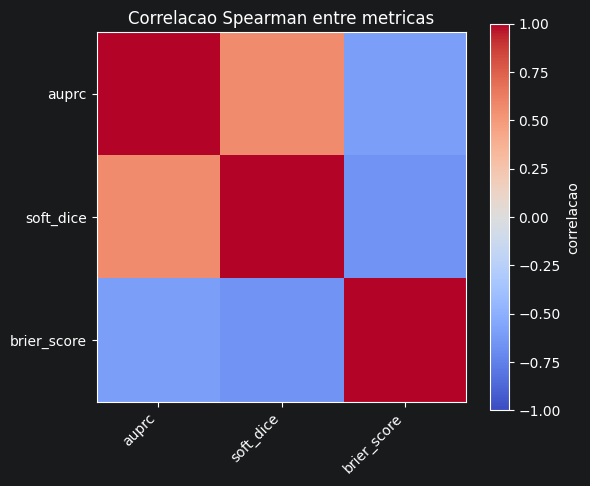

In [6]:
texto_correlacao = 'Aqui avaliamos se as metricas contam historias complementares ou redundantes, usando graficos bivariados e matrizes de correlacao de Pearson e Spearman.'
df_corr_pearson = df_base[metric_names].corr(method='pearson').reset_index().rename(columns={'index': 'metric_name'})
df_corr_spearman = df_base[metric_names].corr(method='spearman').reset_index().rename(columns={'index': 'metric_name'})
display(df_corr_pearson)
display(df_corr_spearman)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_05_segmentacao_bruta', 'tabela', 'correlacao_pearson'), df_corr_pearson)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_05_segmentacao_bruta', 'tabela', 'correlacao_spearman'), df_corr_spearman)

for x_metric, y_metric in metric_pairs:
    df_plot = df_base[['modelo', x_metric, y_metric, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_metric_scatter(df_base, x_metric, y_metric)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'dispersao', y_metric, 'vs', x_metric, 'por_modelo'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)

for method in ['pearson', 'spearman']:
    correlation = df_base[metric_names].corr(method=method).reset_index().rename(columns={'index': 'metric_name'})
    fig, _ = plot_metric_correlation_heatmap(df_base, metric_names, method)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'correlacao', method, 'entre_metricas'),
        fig,
        correlation,
    )
    plt.show()
    plt.close(fig)


## Regressao simples

A regressao simples usa `num_tags_problema` como proxy de dificuldade para medir a tendencia de degradacao das metricas mais interpretaveis para a segmentacao bruta.


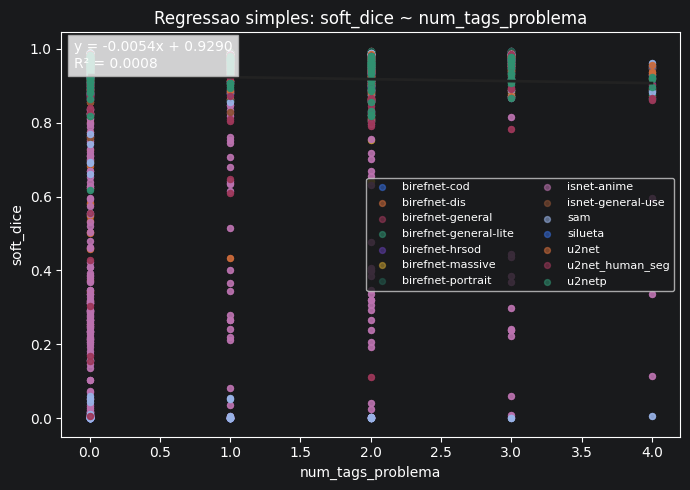

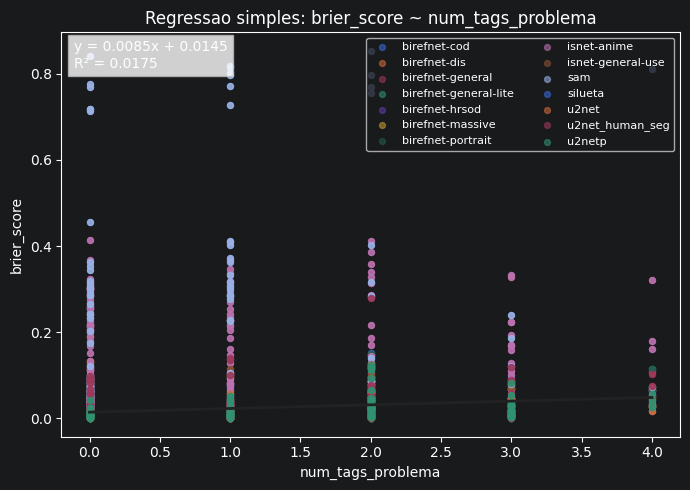

In [7]:
texto_regressao = 'A regressao simples usa num_tags_problema como proxy de dificuldade para medir a tendencia de degradacao das metricas mais interpretaveis para a segmentacao bruta.'

for metric_name in regression_metrics:
    df_plot = df_base[['modelo', 'num_tags_problema', metric_name, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_simple_regression(df_base, 'num_tags_problema', metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'regressao', metric_name, 'vs', 'num_tags_problema'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Interacao entre modelo e dificuldade

Para manter o relatorio sucinto, este bloco mostra as tres metricas brutas principais para enxergar queda de qualidade com dificuldade: `auprc`, `soft_dice` e `brier_score`.


,nome_modelo,tag_name,metric_name,count_com_tag,count_sem_tag,mean_com_tag,mean_sem_tag,median_com_tag,median_sem_tag,delta_mean,delta_median,relative_delta_mean,adjusted_delta_mean,adjusted_delta_median,impact_direction,higher_is_better
90,birefnet-massive,tag_angulo_extremo,auprc,138,1023,0.959719,0.989755,0.996382,0.997611,-0.030036,-0.001228,-0.030347,-0.030036,-0.001228,piora,True
198,u2net,tag_angulo_extremo,auprc,138,1023,0.979895,0.987958,0.991429,0.996053,-0.008064,-0.004624,-0.008162,-0.008064,-0.004624,piora,True
180,silueta,tag_angulo_extremo,auprc,138,1023,0.981317,0.989374,0.993073,0.996514,-0.008058,-0.003442,-0.008144,-0.008058,-0.003442,piora,True
108,birefnet-portrait,tag_angulo_extremo,auprc,138,1023,0.983434,0.987645,0.997204,0.996106,-0.004211,0.001097,-0.004264,-0.004211,0.001097,piora,True
144,isnet-general-use,tag_angulo_extremo,auprc,138,1023,0.988461,0.992337,0.995830,0.998432,-0.003876,-0.002602,-0.003906,-0.003876,-0.002602,piora,True
54,birefnet-general-lite,tag_angulo_extremo,auprc,138,1023,0.983425,0.987064,0.995618,0.994783,-0.003639,0.000834,-0.003687,-0.003639,0.000834,piora,True
0,birefnet-cod,tag_angulo_extremo,auprc,138,1023,0.983709,0.986023,0.996021,0.993975,-0.002314,0.002046,-0.002347,-0.002314,0.002046,piora,True
72,birefnet-hrsod,tag_angulo_extremo,auprc,138,1023,0.994301,0.994079,0.999209,0.998942,0.000222,0.000267,0.000223,0.000222,0.000267,melhora,True
36,birefnet-general,tag_angulo_extremo,auprc,138,1023,0.989974,0.989461,0.996891,0.996486,0.000513,0.000405,0.000519,0.000513,0.000405,melhora,True
234,u2netp,tag_angulo_extremo,auprc,138,1023,0.993405,0.991348,0.998032,0.997700,0.002057,0.000333,0.002075,0.002057,0.000333,melhora,True


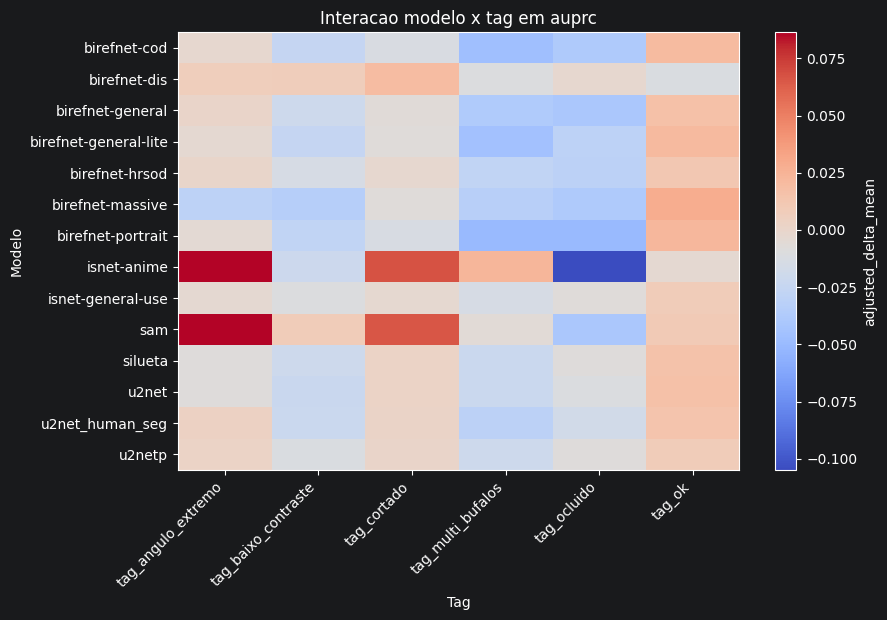

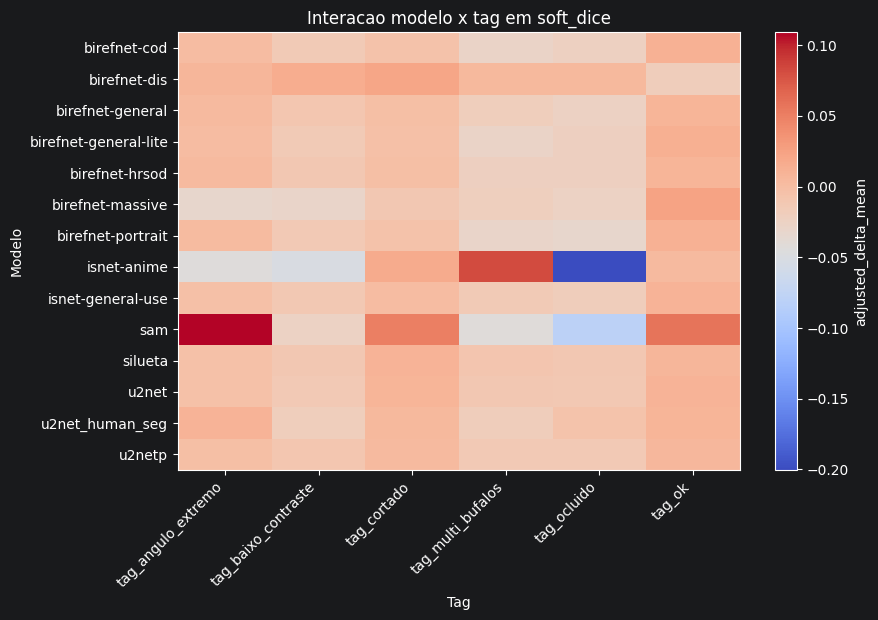

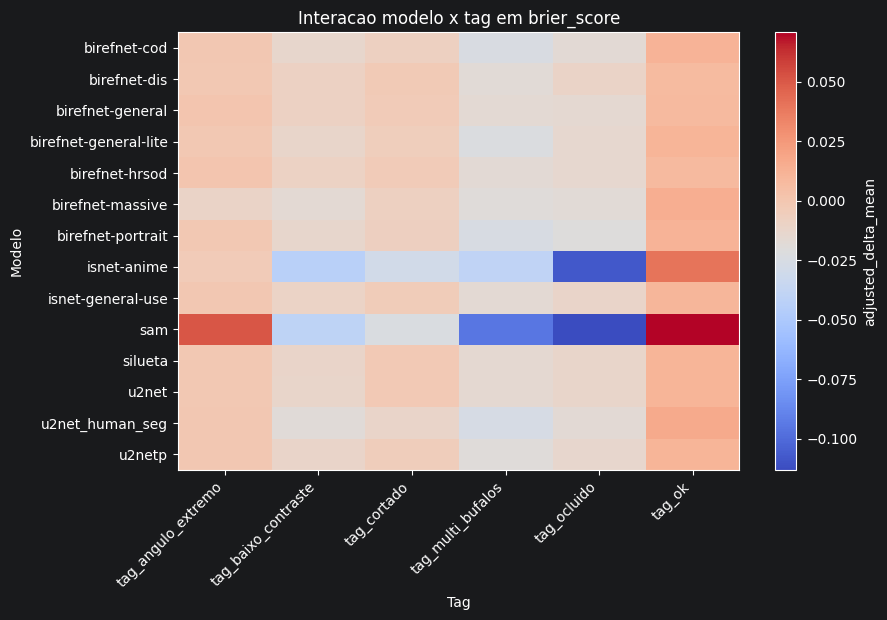

In [8]:
texto_interacoes = 'Para manter o relatorio sucinto, este bloco mostra as tres metricas brutas principais para enxergar queda de qualidade com dificuldade: auprc, soft_dice e brier_score.'
df_tabela_interacoes = df_interacoes_tag_modelo.sort_values(['metric_name', 'tag_name', 'adjusted_delta_mean']).head(20).copy()
display(df_tabela_interacoes)
export_table_csv(
    artifact_output_dir,
    build_artifact_stem('notebook_05_segmentacao_bruta', 'tabela', 'interacao_modelo_tag_top20'),
    df_tabela_interacoes,
)

for metric_name in interaction_metrics:
    df_plot = df_interacoes_tag_modelo.loc[df_interacoes_tag_modelo['metric_name'] == metric_name].copy()
    fig, _ = plot_model_tag_interaction_heatmap(df_interacoes_tag_modelo, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_05_segmentacao_bruta', 'interacao_modelo_tag', metric_name),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Artefatos exportados

Os graficos e tabelas deste notebook sao exportados em PNG e CSV para consumo posterior por IA, sem gerar PDF.


In [9]:
print(f'Artefatos do notebook 05 salvos em: {artifact_output_dir}')


Artefatos do notebook 05 salvos em: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_05_segmentacao_bruta
